<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 146.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 154.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 163.7 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [3]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


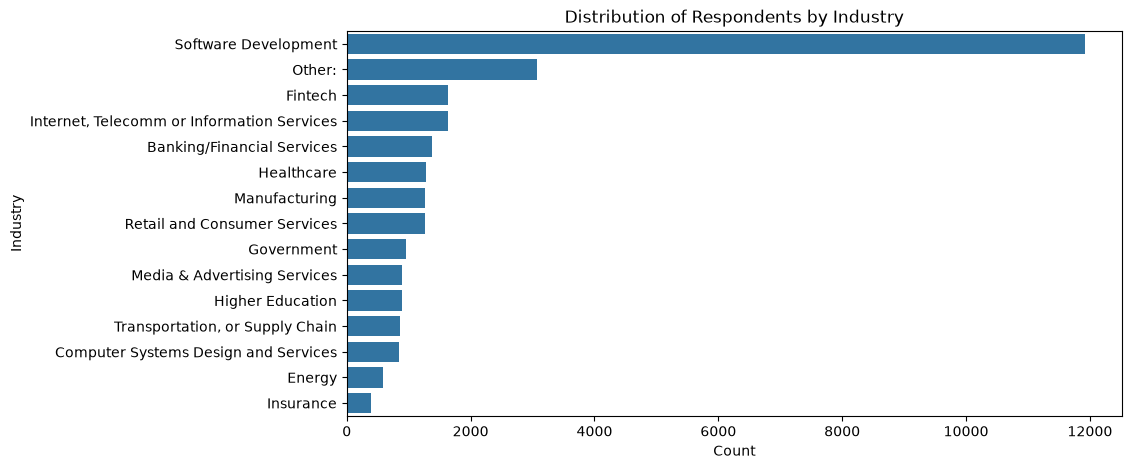

In [4]:
indust = df['Industry'].value_counts().reset_index(name='industryrespcount')
plt.figure(figsize=(10, 5))
sns.barplot(x='industryrespcount', y='Industry', data=indust, orient = 'h')
plt.title("Distribution of Respondents by Industry")
plt.xlabel("Count")
plt.ylabel("Industry")
plt.show()

#Highest number of respondents work in Software Development, followed by Others, followed by Fintech and Internet, Telecomm or Information Services

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
# Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean
df.fillna(df.mean(numeric_only=True), inplace=True)

#Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value
# Select only categorical columns
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
# Loop and fill with each column's most frequent value df['col'].mode()[0]
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    
print("mean:", df['ConvertedCompYearly'].mean())
print("median:", df['ConvertedCompYearly'].median())
print("standard deviation:", df['ConvertedCompYearly'].std())
exceed = df[df['ConvertedCompYearly'] > 3*df['ConvertedCompYearly'].std()+df['ConvertedCompYearly'].mean()]
exceed['ConvertedCompYearly']

mean: 86155.28726264134
median: 86155.28726264134
standard deviation: 111761.3572523415


529       650000.0
594       432000.0
828      1000000.0
920       500000.0
1081      500000.0
           ...    
40188     429429.0
40288     438767.0
40373     644437.0
40952     750000.0
41027     700000.0
Name: ConvertedCompYearly, Length: 193, dtype: float64

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


count    6.543700e+04
mean     8.615529e+04
std      1.117614e+05
min      1.000000e+00
25%      8.615529e+04
50%      8.615529e+04
75%      8.615529e+04
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64
The IQR is: 0.0000
Outlier that exceed max: 15837    16256603.0
Name: ConvertedCompYearly, dtype: float64
Outlier below min: Series([], Name: ConvertedCompYearly, dtype: float64)


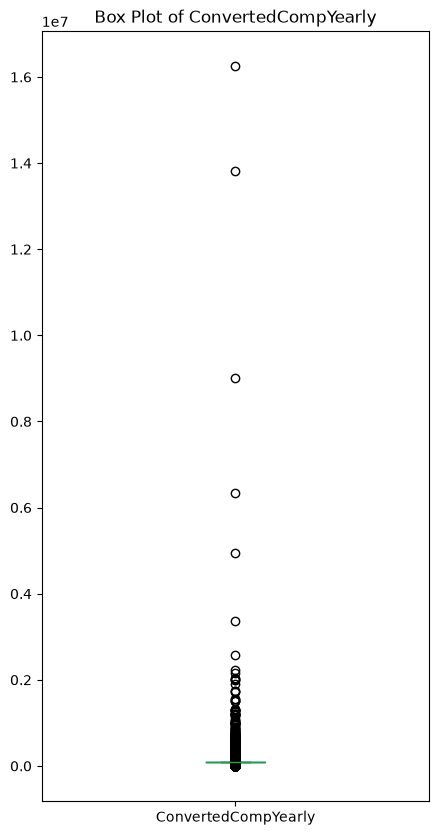

In [6]:
print(df['ConvertedCompYearly'].describe())
#IQR = 3rd quartile (75%)- 1st quartile (25%)
q1 = df['ConvertedCompYearly'].quantile(0.25)
q3 = df['ConvertedCompYearly'].quantile(0.75)
# 3. Calculate IQR
IQR = q3 - q1
print(f"The IQR is: {IQR:.4f}")

# upper bounds for outliers: 1.625660e+07 (max)
# lower bounds for outliers: 1.000000e+00 (min)

#Outliers
exceedd = df[df['ConvertedCompYearly'] > 1.625660e+07]
print ("Outlier that exceed max:", exceedd['ConvertedCompYearly'])
below = df[df['ConvertedCompYearly'] < 1.000000e+00]
print ("Outlier below min:", below['ConvertedCompYearly'])
#Nil outliers below min

plt.figure(figsize=(5, 10))
df['ConvertedCompYearly'].plot(kind='box')
plt.title('Box Plot of ConvertedCompYearly')
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [11]:
new_df = df[df['ConvertedCompYearly'] <= 1.625660e+07]
print("No. of rows, columns of new dataframe:", new_df.shape)

No. of rows, columns of new dataframe: (65436, 114)


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Correlation of Age_numeric and CompTotal: -0.0018039173897947524
Correlation of Age_numeric and WorkExp: 0.49764150122094286
Correlation of Age_numeric and JobSatPoints_1: -0.016383938289519354
Correlation of Age_numeric and JobSatPoints_4: -0.04413740608456344
Correlation of Age_numeric and JobSatPoints_5: -0.05903456672408668
Correlation of Age_numeric and JobSatPoints_6: -0.02938856610610739
Correlation of Age_numeric and JobSatPoints_7: -0.04783588136896527
Correlation of Age_numeric and JobSatPoints_8: -0.0268066205577454
Correlation of Age_numeric and JobSatPoints_9: -0.04748487430169745
Correlation of Age_numeric and JobSatPoints_10: -0.06647059332395856
Correlation of Age_numeric and JobSatPoints_11: -0.06235314735145113
Correlation of Age_numeric and ConvertedCompYearly: 0.07864400117345896
Correlation of Age_numeric and JobSat: 0.04052758320162388


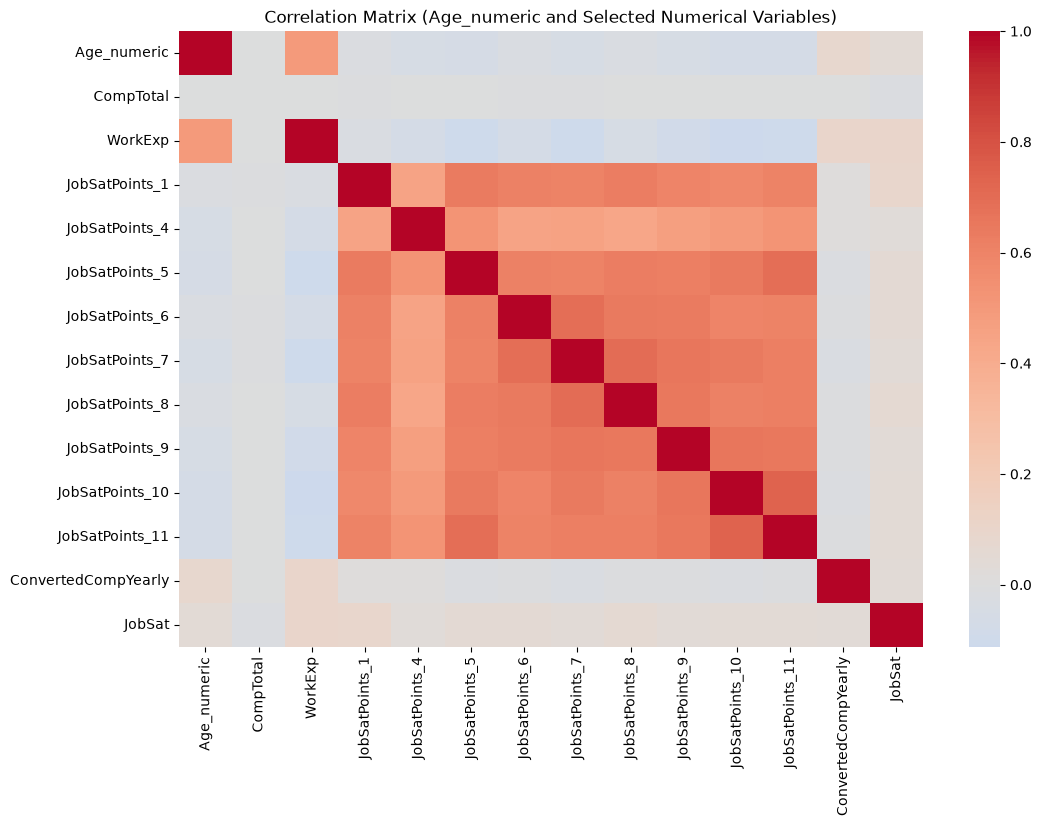

In [22]:
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

# Create a new numeric Age column
new_df['Age_numeric'] = new_df['Age'].map(age_mapping)

# Other numeric variables:CompTotal, WorkExp, JobSatPoints_1, JobSatPoints_4, JobSatPoints_5, JobSatPoints_6, JobSatPoints_7, JobSatPoints_8, JobSatPoints_9, JobSatPoints_10, JobSatPoints_11, ConvertedCompYearly, JobSat
# correlations between Age and other numeric variables
for param in ['CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat']:
    corr = new_df[['Age_numeric', param]].corr().loc['Age_numeric', param]
    print(f"Correlation of Age_numeric and {param}: {corr}") #returns pearson coefficient

cols = ['Age_numeric'] + [
    'CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5',
    'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
    'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat'
]

corr_matrix = new_df[cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Matrix (Age_numeric and Selected Numerical Variables)")
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
